(ch:ml-regression)=
# 회귀: 펭귄 몸무게 예측

이 장에서는 파머 펭귄 데이터셋을 이용하여 펭귄의 몸무게를 예측하는 회귀 문제를 다룬다. 분류가 범주를 예측하는 문제라면, 회귀는 연속적인 숫자를 예측하는 문제이다.

## 프로젝트 흐름
 
 머신러닝 프로젝트는 보통 다음 순서로 진행된다.
 
 1. 문제를 정의한다.
 2. 데이터를 불러오고 구조를 확인한다.
 3. 탐색적 데이터 분석으로 데이터의 특징을 파악한다.
 4. 훈련셋과 테스트셋으로 나눈다.
 5. 머신러닝 모델을 훈련한다.
 6. 테스트셋으로 모델을 평가한다.
 7. 결과를 해석하고 개선 방향을 정한다.
 
 실제 프로젝트에서는 전처리, 특성 공학, 모델 선택, 하이퍼파라미터 튜닝이 훨씬 복잡해질 수 있다. 하지만 기본 뼈대는 위 흐름에서 크게 벗어나지 않는다.

## 데이터셋
 
 파머 펭귄 데이터셋은 남극 팔머 군도에서 관찰된 세 종류의 펭귄에 대한 자료이다. 세 종은 다음과 같다.
 
 - Adelie
 - Chinstrap
 - Gentoo
 
 주요 특성은 다음과 같다.
 
 | 특성 | 설명 |
 | :--- | :--- |
 | `species` | 펭귄 종 |
 | `island` | 관찰된 섬 |
 | `bill_length_mm` | 부리 길이(mm) |
 | `bill_depth_mm` | 부리 깊이(mm) |
 | `flipper_length_mm` | 날개 길이(mm) |
 | `body_mass_g` | 몸무게(g) |
 | `sex` | 성별 |
 | `year` | 관찰 연도 |
 
 자료는 Gorman, Williams, Fraser(2014)의 연구에서 공개된 데이터이며, Allison Horst의 `palmerpenguins` 프로젝트를 통해 널리 사용되고 있다.

머신러닝 프로젝트에 필요한 기본 라이브러리를 불러온다. 
numpy와 pandas는 데이터 처리에, matplotlib와 seaborn은 시각화에 사용한다. scikit-learn에서는 데이터 분할, 표준화, 모델 훈련, 평가 지표 계산에 필요한 도구를 가져온다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

로컬에 저장된 파머 펭귄 CSV 파일을 데이터프레임으로 불러온다. head()는 앞부분 몇 행을 보여주므로, 열 이름과 실제 값의 형태를 빠르게 확인할 수 있다.

In [2]:
penguins = pd.read_csv("data/penguins.csv")
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 데이터 구조 확인
 
 먼저 데이터의 크기, 열 이름, 결측치, 기본 통계량을 확인한다. 이 단계의 목적은 모델을 바로 만드는 것이 아니라, 데이터가 어떤 모양인지 감을 잡는 것이다.

데이터의 행과 열 개수를 확인한다. 머신러닝 프로젝트를 시작할 때 데이터 규모를 파악하면, 이후 훈련셋과 테스트셋의 크기를 이해하기 쉽다.

In [3]:
penguins.shape

(344, 8)

각 열의 자료형과 결측치가 아닌 값의 개수를 확인한다. 수치형 열과 범주형 열을 구분하고, 결측치가 있는 열을 찾기 위해 필요한 단계이다.

In [4]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 27.6 KB


열마다 결측치가 몇 개 있는지 계산한다. 결측치는 모델 훈련 과정에서 오류를 일으킬 수 있으므로, 전처리 전에 반드시 확인해야 한다.

In [5]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

수치형 특성의 기본 통계량을 확인한다. 평균, 표준편차, 최솟값, 최댓값, 사분위수를 보면 값의 범위와 분포를 대략적으로 파악할 수 있다.

In [6]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


분류 타깃인 species의 클래스별 개수를 확인한다. 클래스의 개수가 지나치게 불균형하면 정확도만으로 모델을 평가하기 어려울 수 있다.

In [7]:
penguins["species"].value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

결측치가 많지는 않다. 이 장의 목적은 머신러닝 프로젝트의 큰 흐름을 익히는 것이므로, 결측치가 있는 행을 제거하는 단순한 방법을 사용한다. 실제 프로젝트에서는 결측치가 생긴 원인을 살펴보고, 평균값/중앙값 대체 또는 별도 범주 처리 등 여러 방법을 비교할 수 있다.

결측치가 포함된 행을 제거하여 분석용 데이터프레임을 만든다. 이 장에서는 프로젝트 흐름을 간단히 보여주는 것이 목적이므로, 복잡한 결측치 대체 대신 가장 단순한 방법을 사용한다.

In [8]:
penguins_clean = penguins.dropna().copy()
penguins_clean.shape

(333, 8)

## 탐색적 데이터 분석
 
 탐색적 데이터 분석(EDA)은 모델을 훈련하기 전에 데이터의 패턴을 살펴보는 과정이다. 여기서는 세 가지 질문에 답해 본다.
 
 1. 종별 관측 수는 어느 정도인가?
 2. 신체 측정값의 분포는 종마다 어떻게 다른가?
 3. 어떤 특성이 종 분류나 몸무게 예측에 도움이 될까?

종별 관측 수와 섬별 종 분포를 막대그래프로 확인한다. 이 시각화는 데이터가 어떤 종으로 구성되어 있는지, 특정 종이 특정 섬에 치우쳐 관찰되었는지 살펴보기 위해 필요하다.

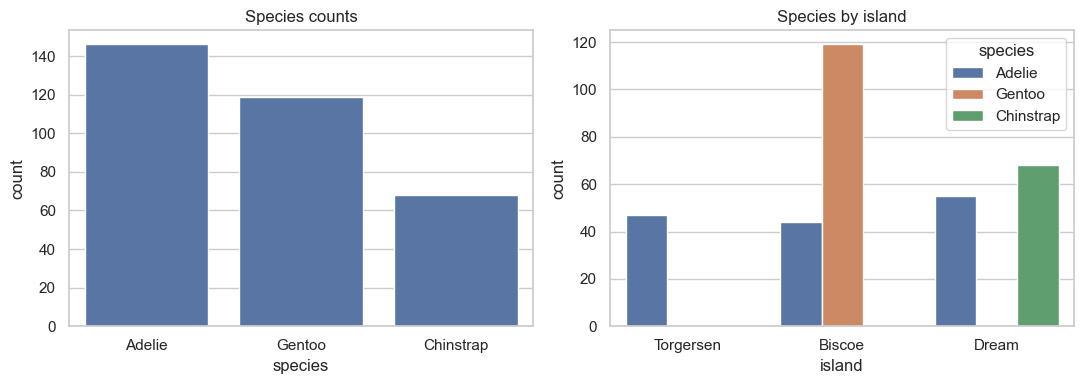

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=penguins_clean, x="species", ax=axes[0])
axes[0].set_title("Species counts")
axes[0].set_xlabel("species")
axes[0].set_ylabel("count")

sns.countplot(data=penguins_clean, x="island", hue="species", ax=axes[1])
axes[1].set_title("Species by island")
axes[1].set_xlabel("island")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

주요 신체 측정값의 종별 분포를 상자그림으로 비교한다. 상자그림을 보면 종마다 값의 중심과 퍼짐이 어떻게 다른지 한눈에 볼 수 있다.

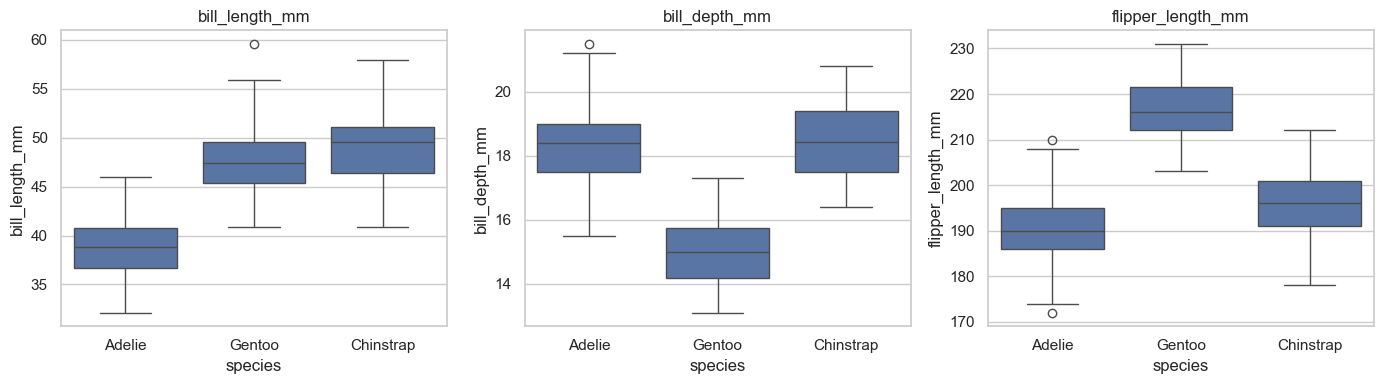

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

numeric_features = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm"]
for feature, ax in zip(numeric_features, axes):
    sns.boxplot(data=penguins_clean, x="species", y=feature, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel("species")

plt.tight_layout()
plt.show()

부리 길이와 부리 깊이를 이용해 종별 산점도를 그린다. 두 특성의 조합만으로도 종이 어느 정도 구분되는지 확인할 수 있어, 분류 문제의 가능성을 직관적으로 보여준다.

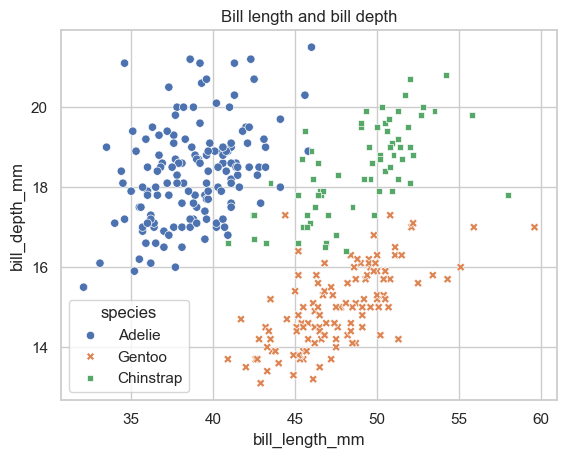

In [11]:
sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    style="species",
)
plt.title("Bill length and bill depth")
plt.show()

수치형 특성들 사이의 상관계수를 계산하고 히트맵으로 시각화한다. 상관계수는 두 변수가 함께 증가하거나 감소하는 경향을 요약하며, 회귀 문제에서 유용한 특성을 고르는 데 도움을 준다.

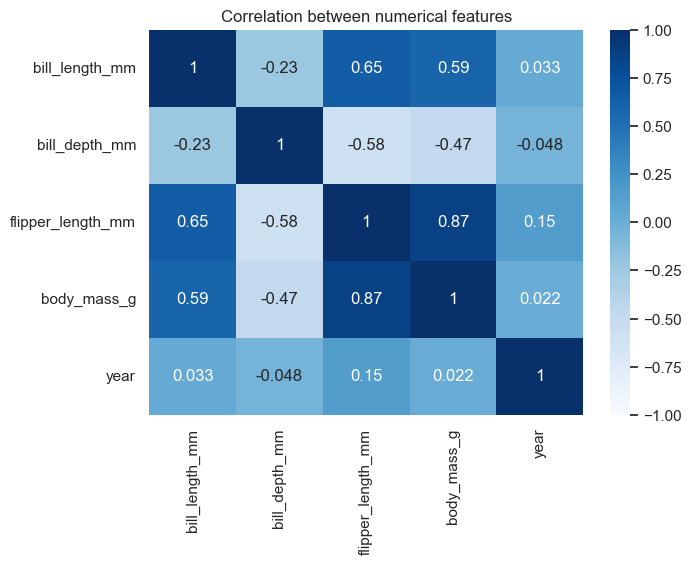

In [12]:
corr = penguins_clean.select_dtypes(include="number").corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1)
plt.title("Correlation between numerical features")
plt.show()

EDA 결과에서 다음을 확인할 수 있다.
 
 - 종마다 부리 길이와 부리 깊이의 조합이 다르게 나타난다.
 - Gentoo 펭귄은 대체로 날개가 길고 몸무게도 무겁다.
 - `flipper_length_mm`와 `body_mass_g` 사이에는 비교적 강한 양의 상관관계가 있다.
 
 이제 이 관찰을 바탕으로 두 가지 머신러닝 문제를 구성한다.

## 회귀 문제 준비

이번에는 `body_mass_g`를 타깃으로 두고, 부리 길이, 부리 깊이, 날개 길이를 입력 특성으로 사용한다. 몸무게는 연속적인 수치이므로 이 문제는 회귀 문제이다.

In [13]:
regression_features = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
]

X_reg = penguins_clean[regression_features]
y_reg = penguins_clean["body_mass_g"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42,
    stratify=penguins_clean["species"],
)

선형 회귀 모델을 훈련하기 전에 수치형 특성을 표준화한다. 훈련셋에서 계산한 평균과 표준편차를 테스트셋에도 그대로 적용해야 테스트셋 정보가 훈련 과정에 섞이지 않는다.

In [14]:
reg_scaler = StandardScaler()

X_reg_train_scaled = pd.DataFrame(
    reg_scaler.fit_transform(X_reg_train),
    columns=regression_features,
    index=X_reg_train.index,
)
X_reg_test_scaled = pd.DataFrame(
    reg_scaler.transform(X_reg_test),
    columns=regression_features,
    index=X_reg_test.index,
)

In [15]:
reg_model = LinearRegression()
reg_model.fit(X_reg_train_scaled, y_reg_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


테스트셋의 몸무게를 예측하고 MAE, RMSE, R2 점수를 계산한다. 여러 평가 지표를 함께 보면 오차의 평균적인 크기와 모델의 설명력을 동시에 판단할 수 있다.

In [16]:
y_reg_pred = reg_model.predict(X_reg_test_scaled)

mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

pd.DataFrame(
    {
        "metric": ["MAE", "RMSE", "R2"],
        "value": [mae, rmse, r2],
    }
)

,metric,value
0,MAE,323.588878
1,RMSE,403.042894
2,R2,0.733278


실제 몸무게와 예측 몸무게를 하나의 데이터프레임으로 정리한다. 몇 개의 예측 결과를 직접 비교하면 평가 지표만 볼 때보다 모델의 예측 수준을 더 구체적으로 이해할 수 있다.

In [17]:
results = pd.DataFrame({
    "actual": y_reg_test,
    "predicted": y_reg_pred,
})

results.head(10)

,actual,predicted
262,5000.0,4969.526739
338,3650.0,3908.762011
93,4450.0,3443.127087
240,4875.0,4741.590840
222,4750.0,4956.849876
168,4150.0,4614.063062
327,3950.0,4257.446943
25,3800.0,3487.400622
113,4275.0,4026.718491
190,4350.0,4521.249496


실제값과 예측값을 산점도로 비교한다. 빨간 점선은 실제값과 예측값이 완전히 같은 경우를 나타내며, 점들이 이 선에 가까울수록 예측이 잘 된 것이다.

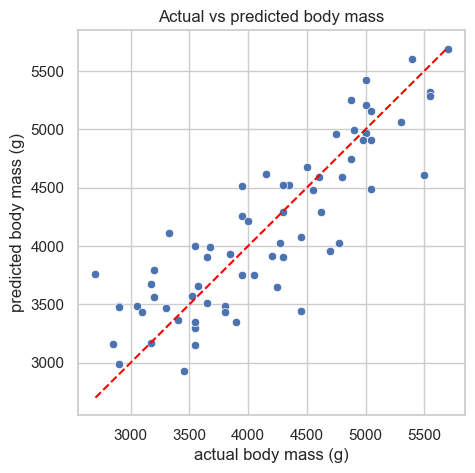

In [18]:
plt.figure(figsize=(5, 5))
sns.scatterplot(data=results, x="actual", y="predicted")

min_value = min(results["actual"].min(), results["predicted"].min())
max_value = max(results["actual"].max(), results["predicted"].max())
plt.plot([min_value, max_value], [min_value, max_value], color="red", linestyle="--")

plt.title("Actual vs predicted body mass")
plt.xlabel("actual body mass (g)")
plt.ylabel("predicted body mass (g)")
plt.show()

MAE는 예측값이 실제값에서 평균적으로 얼마나 벗어났는지를 그램 단위로 보여준다. RMSE는 큰 오차에 더 민감한 지표이다. R2 점수는 입력 특성이 타깃의 변동을 어느 정도 설명하는지 나타내며, 1에 가까울수록 좋다.

## 정리

이번 장에서는 펭귄 몸무게 예측 문제를 통해 회귀 모델의 기본 흐름을 살펴보았다.

- 회귀는 연속적인 수치를 예측하는 문제이다.
- 훈련셋과 테스트셋을 나누어 모델이 처음 보는 데이터에서도 잘 작동하는지 확인한다.
- MAE, RMSE, R2는 회귀 모델의 성능을 서로 다른 관점에서 보여준다.
- 실제값과 예측값을 산점도로 비교하면 모델의 예측 수준을 직관적으로 볼 수 있다.

여기서는 회귀의 전체 흐름을 단순하게 보기 위해 작은 펭귄 데이터셋을 사용했다. 더 복잡한 회귀 문제에서는 더 많은 특성, 범주형 변수 처리, 특성 선택, 모델 비교 등이 함께 필요할 수 있다.

## 연습문제

**문제 1**

`bill_length_mm`, `bill_depth_mm`만 사용하여 몸무게를 예측해 보아라. 세 특성을 모두 사용했을 때와 성능이 어떻게 달라지는가?

**문제 2**

`flipper_length_mm` 하나만 사용하여 몸무게를 예측해 보아라. 산점도에서 보았던 관계가 회귀 성능에도 반영되는가?

**문제 3**

훈련셋과 테스트셋을 나눌 때 `stratify` 옵션을 제거해 보아라. 평가 결과가 달라지는지 확인해 보아라.